In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, classification_report, confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SVM MODEL TRAINING - COMPREHENSIVE COMPARISON")
print("="*80)

SVM MODEL TRAINING - COMPREHENSIVE COMPARISON


## Import Libraries

## Step 1: Load and Prepare Data

In [6]:
print("[1/6] Loading cleaned data...")
try:
    train_df = pd.read_csv('../dataset/train_dropped_column_20pct_sample.csv')
    test_df = pd.read_csv('../dataset/test_dropped_column.csv')
    print(f"✓ Training data loaded: {train_df.shape}")
    print(f"✓ Test data loaded: {test_df.shape}")
except FileNotFoundError:
    print("✗ Error: Cleaned data files not found. Please run data_cleaning.ipynb first.")
    raise

[1/6] Loading cleaned data...
✓ Training data loaded: (11922, 23)
✓ Test data loaded: (14900, 22)


## Step 2: Prepare Features and Target

In [7]:
print("[2/6] Preparing features and target variable...")

# Separate features and target
X = train_df.drop(['retention_status', 'founder_id'], axis=1)
y = train_df['retention_status']

# Store test IDs for submission
test_ids = test_df['founder_id'].copy()
X_test = test_df.drop(['founder_id'], axis=1, errors='ignore')

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"✓ Target classes: {le.classes_}")
print(f"✓ Class distribution: {dict(zip(*np.unique(y_encoded, return_counts=True)))}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n✓ Categorical features: {len(categorical_cols)}")
print(f"✓ Numerical features: {len(numerical_cols)}")

[2/6] Preparing features and target variable...
✓ Target classes: ['Left' 'Stayed']
✓ Class distribution: {0: 5697, 1: 6225}

✓ Categorical features: 15
✓ Numerical features: 6


## Step 3: Encode Categorical Variables

In [8]:
print("[3/6] Encoding categorical variables...")

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le_temp = LabelEncoder()
    X[col] = le_temp.fit_transform(X[col].astype(str))
    X_test[col] = le_temp.transform(X_test[col].astype(str))
    label_encoders[col] = le_temp

print(f"✓ Encoded {len(categorical_cols)} categorical columns")

[3/6] Encoding categorical variables...
✓ Encoded 15 categorical columns


## Step 4: Split Data into Train/Val (80%) and Evaluation (20%)

First split: 80% for training/validation, 20% for final evaluation
Second split: Split the 80% into train (80%) and validation (20%)

In [9]:
print("[4/6] Splitting data - 80% train/val, 20% evaluation...")

# First split: 80% for training/validation, 20% for final evaluation
X_trainval, X_eval, y_trainval, y_eval = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"✓ Train/Val set (80%): {X_trainval.shape}")
print(f"✓ Evaluation set (20%): {X_eval.shape}")

# Second split: Split the 80% into train (80%) and validation (20%)
# This gives us 64% train, 16% val, 20% eval of original data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"✓ Training set (64% of original): {X_train.shape}")
print(f"✓ Validation set (16% of original): {X_val.shape}")

# Scale features (critical for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_eval_scaled = scaler.transform(X_eval)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

[4/6] Splitting data - 80% train/val, 20% evaluation...
✓ Train/Val set (80%): (9537, 21)
✓ Evaluation set (20%): (2385, 21)
✓ Train/Val set (80%): (9537, 21)
✓ Evaluation set (20%): (2385, 21)
✓ Training set (64% of original): (7629, 21)
✓ Validation set (16% of original): (1908, 21)
✓ Features scaled using StandardScaler
✓ Training set (64% of original): (7629, 21)
✓ Validation set (16% of original): (1908, 21)
✓ Features scaled using StandardScaler


## Step 5: Train Multiple SVM Models

We'll train and compare 5 different SVM variants with hyperparameter tuning.

In [10]:
print("[5/6] Training and comparing multiple SVM models...")
print("-"*80)

results = []

# Define SVM configurations with pre-selected reasonable parameters
svm_configs = [
    {
        'name': 'Linear SVM',
        'params': {
            'kernel': 'linear',
            'C': 1.0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'RBF SVM',
        'params': {
            'kernel': 'rbf',
            'C': 10.0,
            'gamma': 'scale',
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Polynomial SVM (degree=2)',
        'params': {
            'kernel': 'poly',
            'degree': 2,
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Polynomial SVM (degree=3)',
        'params': {
            'kernel': 'poly',
            'degree': 3,
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    },
    {
        'name': 'Sigmoid SVM',
        'params': {
            'kernel': 'sigmoid',
            'C': 1.0,
            'gamma': 'scale',
            'coef0': 0,
            'class_weight': 'balanced'
        }
    }
]

best_overall_score = 0
best_overall_model = None
best_overall_name = None

[5/6] Training and comparing multiple SVM models...
--------------------------------------------------------------------------------


In [11]:
# Train each SVM configuration
for config in svm_configs:
    print(f"\nTraining {config['name']}...")
    start_time = time.time()
    
    # Create SVM with specified parameters
    model = SVC(random_state=42, probability=True, **config['params'])
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    training_time = time.time() - start_time
    best_model = model
    
    # Predictions
    y_val_pred = best_model.predict(X_val_scaled)
    y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, average='weighted')
    recall = recall_score(y_val, y_val_pred, average='weighted')
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_val_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    result = {
        'Model': config['name'],
        'Best_Params': config['params'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std,
        'Training_Time': training_time,
        'Model_Object': best_model
    }
    results.append(result)
    
    # Print results
    print(f"  Parameters: {config['params']}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  CV Score: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Training time: {training_time:.2f}s")
    
    # Track best model
    if accuracy > best_overall_score:
        best_overall_score = accuracy
        best_overall_model = best_model
        best_overall_name = config['name']


Training Linear SVM...
  Parameters: {'kernel': 'linear', 'C': 1.0, 'class_weight': 'balanced'}
  Accuracy: 0.7159
  Precision: 0.7180
  Recall: 0.7159
  F1-Score: 0.7160
  ROC-AUC: 0.7900
  CV Score: 0.7038 (+/- 0.0111)
  Training time: 11.15s

Training RBF SVM...
  Parameters: {'kernel': 'linear', 'C': 1.0, 'class_weight': 'balanced'}
  Accuracy: 0.7159
  Precision: 0.7180
  Recall: 0.7159
  F1-Score: 0.7160
  ROC-AUC: 0.7900
  CV Score: 0.7038 (+/- 0.0111)
  Training time: 11.15s

Training RBF SVM...
  Parameters: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'balanced'}
  Accuracy: 0.7123
  Precision: 0.7132
  Recall: 0.7123
  F1-Score: 0.7124
  ROC-AUC: 0.7779
  CV Score: 0.6918 (+/- 0.0079)
  Training time: 11.55s

Training Polynomial SVM (degree=2)...
  Parameters: {'kernel': 'rbf', 'C': 10.0, 'gamma': 'scale', 'class_weight': 'balanced'}
  Accuracy: 0.7123
  Precision: 0.7132
  Recall: 0.7123
  F1-Score: 0.7124
  ROC-AUC: 0.7779
  CV Score: 0.6918 (+/- 0.0079)

## Step 6: Display Results and Select Best Model

In [12]:
print("\n" + "="*80)
print("[6/6] FINAL RESULTS - MODEL COMPARISON")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame([{
    'Model': r['Model'],
    'Accuracy': r['Accuracy'],
    'Precision': r['Precision'],
    'Recall': r['Recall'],
    'F1-Score': r['F1_Score'],
    'ROC-AUC': r['ROC_AUC'],
    'CV_Mean': r['CV_Mean'],
    'CV_Std': r['CV_Std'],
    'Time(s)': r['Training_Time']
} for r in results])

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\nPerformance Comparison:")
print(results_df.to_string(index=False))


[6/6] FINAL RESULTS - MODEL COMPARISON

Performance Comparison:
                    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean   CV_Std   Time(s)
               Linear SVM  0.715933   0.718015 0.715933  0.716009 0.789995 0.703763 0.011128 11.150711
                  RBF SVM  0.712264   0.713201 0.712264  0.712404 0.777874 0.691834 0.007932 11.551738
Polynomial SVM (degree=3)  0.703878   0.707924 0.703878  0.703678 0.774966 0.688688 0.003996  6.412063
Polynomial SVM (degree=2)  0.674528   0.684268 0.674528  0.672801 0.705507 0.650674 0.004101  7.991660
              Sigmoid SVM  0.664570   0.665796 0.664570  0.664727 0.709749 0.663784 0.003477  9.176952


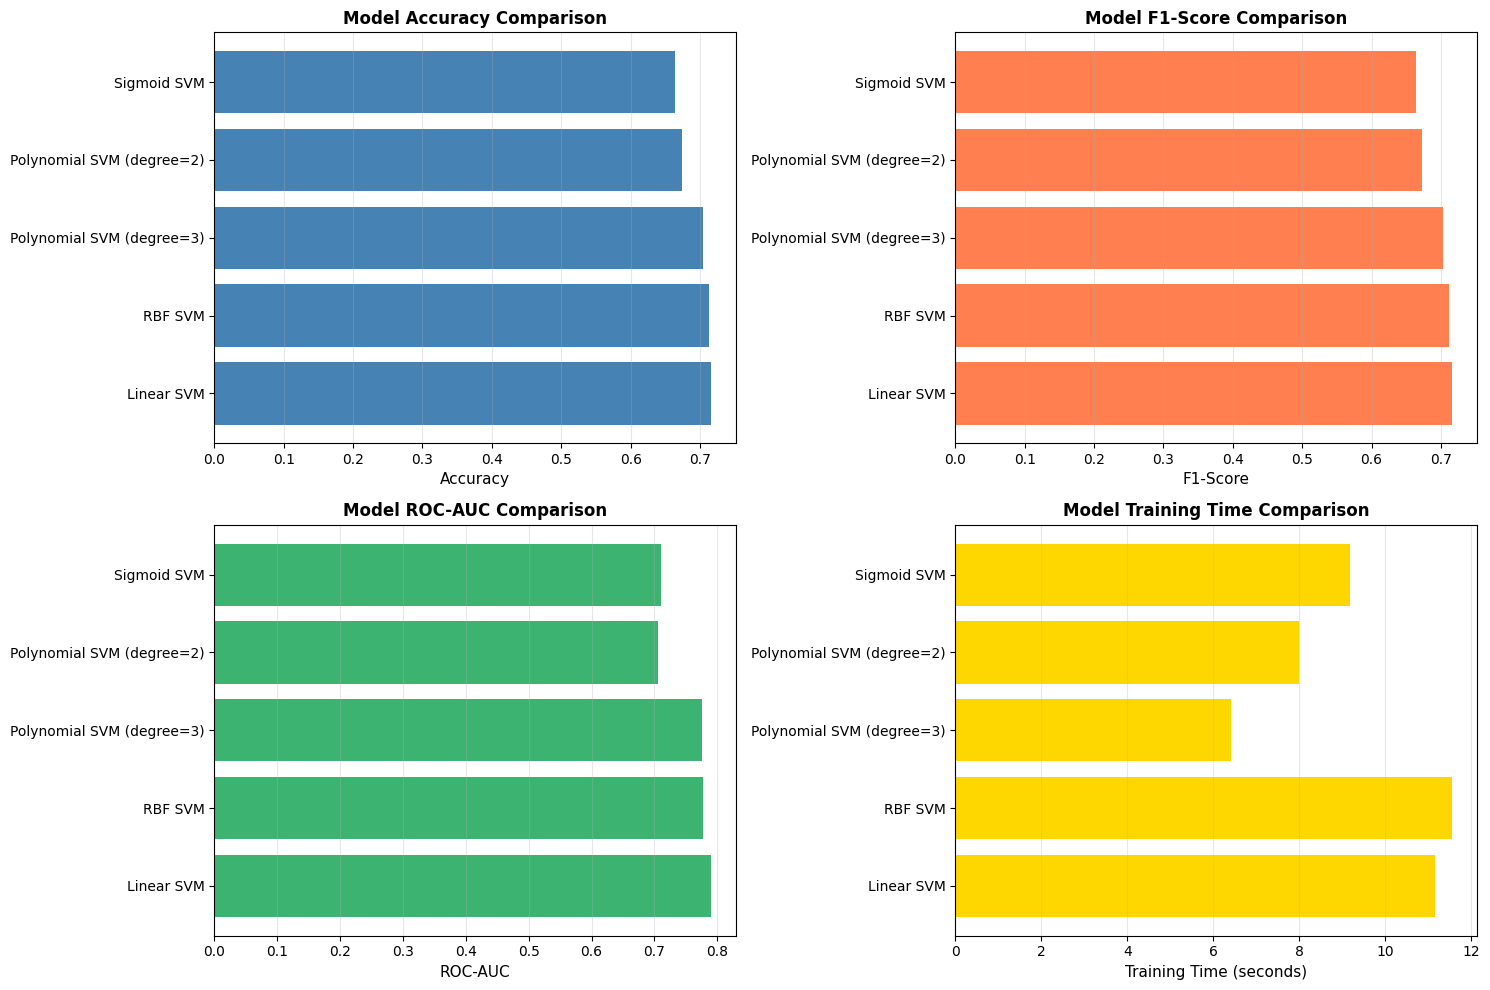

In [13]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# F1-Score comparison
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='coral')
axes[0, 1].set_xlabel('F1-Score', fontsize=11)
axes[0, 1].set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# ROC-AUC comparison
axes[1, 0].barh(results_df['Model'], results_df['ROC-AUC'], color='mediumseagreen')
axes[1, 0].set_xlabel('ROC-AUC', fontsize=11)
axes[1, 0].set_title('Model ROC-AUC Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Training time comparison
axes[1, 1].barh(results_df['Model'], results_df['Time(s)'], color='gold')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=11)
axes[1, 1].set_title('Model Training Time Comparison', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Best Model Details

## Evaluate Best Model on Held-Out Evaluation Set (20%)

In [14]:
print("="*80)
print("EVALUATION ON HELD-OUT 20% EVALUATION SET")
print("="*80)

# Predict on evaluation set
y_eval_pred = best_overall_model.predict(X_eval_scaled)
y_eval_proba = best_overall_model.predict_proba(X_eval_scaled)[:, 1]

# Calculate metrics on evaluation set
eval_accuracy = accuracy_score(y_eval, y_eval_pred)
eval_precision = precision_score(y_eval, y_eval_pred, average='weighted')
eval_recall = recall_score(y_eval, y_eval_pred, average='weighted')
eval_f1 = f1_score(y_eval, y_eval_pred, average='weighted')
eval_roc_auc = roc_auc_score(y_eval, y_eval_proba)

print(f"\nEvaluation Set Performance (on held-out 20%):")
print(f"  • Accuracy:  {eval_accuracy:.4f}")
print(f"  • Precision: {eval_precision:.4f}")
print(f"  • Recall:    {eval_recall:.4f}")
print(f"  • F1-Score:  {eval_f1:.4f}")
print(f"  • ROC-AUC:   {eval_roc_auc:.4f}")

print("\n" + "-"*80)
print("Detailed Classification Report (Evaluation Set):")
print("-"*80)
print(classification_report(y_eval, y_eval_pred, target_names=le.classes_))

EVALUATION ON HELD-OUT 20% EVALUATION SET

Evaluation Set Performance (on held-out 20%):
  • Accuracy:  0.7153
  • Precision: 0.7155
  • Recall:    0.7153
  • F1-Score:  0.7154
  • ROC-AUC:   0.7840

--------------------------------------------------------------------------------
Detailed Classification Report (Evaluation Set):
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        Left       0.70      0.71      0.70      1140
      Stayed       0.73      0.72      0.73      1245

    accuracy                           0.72      2385
   macro avg       0.71      0.72      0.71      2385
weighted avg       0.72      0.72      0.72      2385




Confusion Matrix (Evaluation Set):
[[809 331]
 [348 897]]

True Negatives:  809
False Positives: 331
False Negatives: 348
True Positives:  897


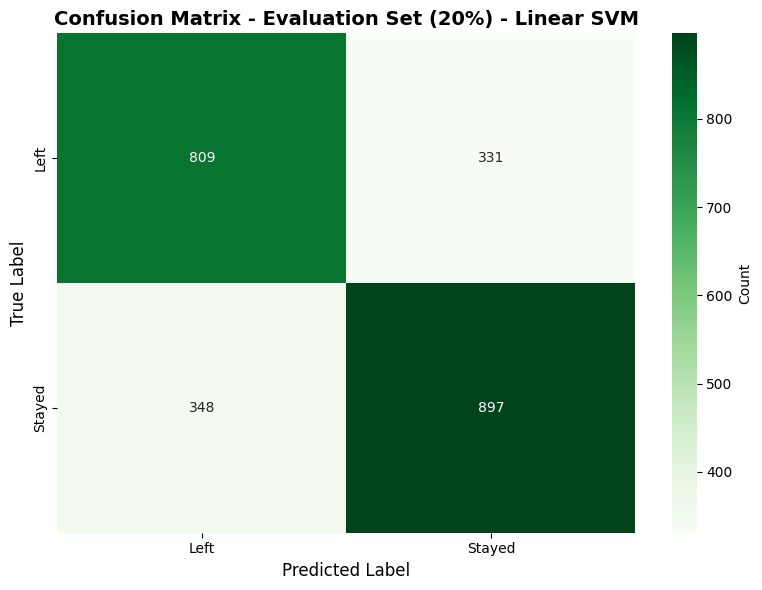

In [15]:
# Confusion matrix for evaluation set
print("\nConfusion Matrix (Evaluation Set):")
cm_eval = confusion_matrix(y_eval, y_eval_pred)
print(cm_eval)
print(f"\nTrue Negatives:  {cm_eval[0][0]}")
print(f"False Positives: {cm_eval[0][1]}")
print(f"False Negatives: {cm_eval[1][0]}")
print(f"True Positives:  {cm_eval[1][1]}")

# Visualize confusion matrix for evaluation set
plt.figure(figsize=(8, 6))
sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Evaluation Set (20%) - {best_overall_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Display best model
print("="*80)
print(f"🏆 BEST MODEL: {best_overall_name}")
print("="*80)

best_result = next(r for r in results if r['Model'] == best_overall_name)
print(f"\nBest Parameters: {best_result['Best_Params']}")
print(f"\nPerformance Metrics:")
print(f"  • Accuracy:  {best_result['Accuracy']:.4f}")
print(f"  • Precision: {best_result['Precision']:.4f}")
print(f"  • Recall:    {best_result['Recall']:.4f}")
print(f"  • F1-Score:  {best_result['F1_Score']:.4f}")
print(f"  • ROC-AUC:   {best_result['ROC_AUC']:.4f}")
print(f"  • CV Score:  {best_result['CV_Mean']:.4f} (+/- {best_result['CV_Std']:.4f})")

🏆 BEST MODEL: Linear SVM

Best Parameters: {'kernel': 'linear', 'C': 1.0, 'class_weight': 'balanced'}

Performance Metrics:
  • Accuracy:  0.7159
  • Precision: 0.7180
  • Recall:    0.7159
  • F1-Score:  0.7160
  • ROC-AUC:   0.7900
  • CV Score:  0.7038 (+/- 0.0111)


In [17]:
# Detailed classification report
print("\n" + "-"*80)
print("Detailed Classification Report:")
print("-"*80)
y_val_pred_best = best_overall_model.predict(X_val_scaled)
print(classification_report(y_val, y_val_pred_best, target_names=le.classes_))


--------------------------------------------------------------------------------
Detailed Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        Left       0.69      0.74      0.71       912
      Stayed       0.75      0.69      0.72       996

    accuracy                           0.72      1908
   macro avg       0.72      0.72      0.72      1908
weighted avg       0.72      0.72      0.72      1908




Confusion Matrix:
[[676 236]
 [306 690]]

True Negatives:  676
False Positives: 236
False Negatives: 306
True Positives:  690


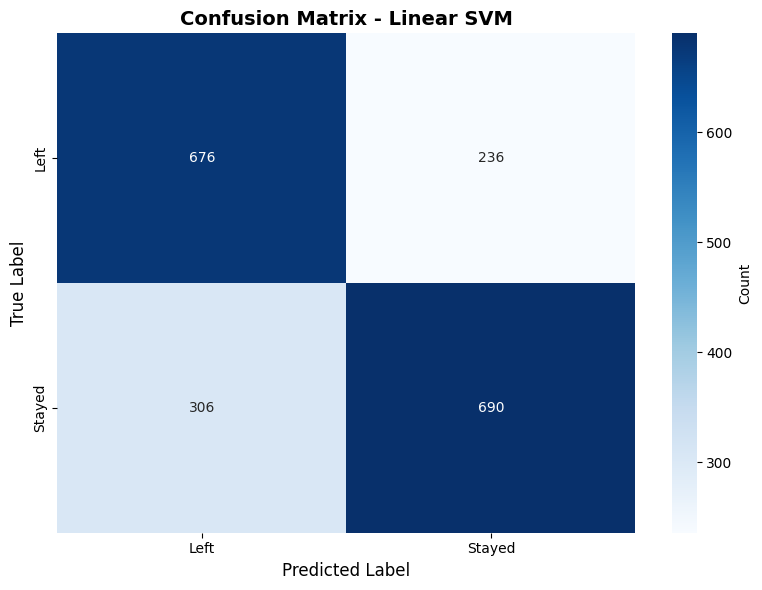

In [18]:
# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_best)
print(cm)
print(f"\nTrue Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_overall_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Generate Predictions on Test Set

In [19]:
print("="*80)
print("GENERATING TEST SET PREDICTIONS")
print("="*80)

# Predict on test set
test_predictions = best_overall_model.predict(X_test_scaled)
test_predictions_labels = le.inverse_transform(test_predictions)
test_predictions_proba = best_overall_model.predict_proba(X_test_scaled)

# Create submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': test_predictions_labels
})

submission.to_csv('test_predictions_best_svm_20pct.csv', index=False)
print(f"\n✓ Predictions saved to: test_predictions_best_svm_20pct.csv")
print(f"✓ Number of predictions: {len(submission)}")
print(f"\nPrediction distribution:")
print(submission['retention_status'].value_counts())

# Save predictions with probabilities
submission_with_probs = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': test_predictions_labels,
    'prob_Left': test_predictions_proba[:, 0],
    'prob_Stayed': test_predictions_proba[:, 1]
})

submission_with_probs.to_csv('test_predictions_best_svm_20pct_with_probs.csv', index=False)
print(f"✓ Predictions with probabilities saved to: test_predictions_best_svm_20pct_with_probs.csv")

GENERATING TEST SET PREDICTIONS

✓ Predictions saved to: test_predictions_best_svm_20pct.csv
✓ Number of predictions: 14900

Prediction distribution:
retention_status
Stayed    7502
Left      7398
Name: count, dtype: int64
✓ Predictions with probabilities saved to: test_predictions_best_svm_20pct_with_probs.csv


In [20]:
# Save best model details with evaluation metrics
with open('best_svm_model_summary_20pct.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("BEST SVM MODEL SUMMARY - 20% SAMPLE WITH EVAL SET\n")
    f.write("="*80 + "\n\n")
    f.write(f"Data Split:\n")
    f.write(f"  - Training/Validation: 80% of data\n")
    f.write(f"  - Training: 64% of original data\n")
    f.write(f"  - Validation: 16% of original data\n")
    f.write(f"  - Evaluation (held-out): 20% of original data\n\n")
    f.write(f"Model: {best_overall_name}\n")
    f.write(f"Best Parameters: {best_result['Best_Params']}\n\n")
    f.write("Validation Set Performance:\n")
    f.write(f"  Accuracy:  {best_result['Accuracy']:.4f}\n")
    f.write(f"  Precision: {best_result['Precision']:.4f}\n")
    f.write(f"  Recall:    {best_result['Recall']:.4f}\n")
    f.write(f"  F1-Score:  {best_result['F1_Score']:.4f}\n")
    f.write(f"  ROC-AUC:   {best_result['ROC_AUC']:.4f}\n")
    f.write(f"  CV Score:  {best_result['CV_Mean']:.4f} (+/- {best_result['CV_Std']:.4f})\n\n")
    f.write("Evaluation Set Performance (Held-out 20%):\n")
    f.write(f"  Accuracy:  {eval_accuracy:.4f}\n")
    f.write(f"  Precision: {eval_precision:.4f}\n")
    f.write(f"  Recall:    {eval_recall:.4f}\n")
    f.write(f"  F1-Score:  {eval_f1:.4f}\n")
    f.write(f"  ROC-AUC:   {eval_roc_auc:.4f}\n\n")
    f.write("All Models Comparison:\n")
    f.write(results_df.to_string(index=False))

print("\n✓ Model summary saved to: best_svm_model_summary_20pct.txt")


✓ Model summary saved to: best_svm_model_summary_20pct.txt


In [21]:
print("\n" + "="*80)
print("✓ TRAINING COMPLETE!")
print("="*80)
print(f"\nData Split Summary:")
print(f"  • Training: {X_train.shape[0]} samples (64% of original)")
print(f"  • Validation: {X_val.shape[0]} samples (16% of original)")
print(f"  • Evaluation: {X_eval.shape[0]} samples (20% of original)")
print(f"  • Test: {X_test.shape[0]} samples (full test set)")
print(f"\nValidation Accuracy: {best_result['Accuracy']:.4f}")
print(f"Evaluation Accuracy: {eval_accuracy:.4f}")
print(f"Best Model: {best_overall_name}")
print("\nOutput files:")
print("  1. test_predictions_best_svm_20pct.csv - Test set predictions")
print("  2. test_predictions_best_svm_20pct_with_probs.csv - Predictions with probabilities")
print("  3. best_svm_model_summary_20pct.txt - Detailed model summary")


✓ TRAINING COMPLETE!

Data Split Summary:
  • Training: 7629 samples (64% of original)
  • Validation: 1908 samples (16% of original)
  • Evaluation: 2385 samples (20% of original)
  • Test: 14900 samples (full test set)

Validation Accuracy: 0.7159
Evaluation Accuracy: 0.7153
Best Model: Linear SVM

Output files:
  1. test_predictions_best_svm_20pct.csv - Test set predictions
  2. test_predictions_best_svm_20pct_with_probs.csv - Predictions with probabilities
  3. best_svm_model_summary_20pct.txt - Detailed model summary
